In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_long = pd.read_csv('df_long.csv')
pd.set_option('display.max_columns', None)
# display(df_long)
print(df_long)

       iid  gender  condtn  wave  round  position  order  partner    pid  \
0        1       0       1     1     10         7      1        7   17.0   
1        1       0       1     1     10         7      1        7   17.0   
2        1       0       1     1     10         7      1        7   17.0   
3        1       0       1     1     10         7      1        7   17.0   
4        1       0       1     1     10         7      1        7   17.0   
...    ...     ...     ...   ...    ...       ...    ...      ...    ...   
37885  552       1       2    21     22        18      9        8  516.0   
37886  552       1       2    21     22        18      9        8  516.0   
37887  552       1       2    21     22        18      9        8  516.0   
37888  552       1       2    21     22        18      9        8  516.0   
37889  552       1       2    21     22        18      9        8  516.0   

       match  int_corr  samerace  age_o  race_o  pf_o_att  pf_o_sin  pf_o_int  \
0     

In [3]:
print(f"df_long.shape:\n{df_long.shape}\n")
print(f"df_long.columns.tolist():\n{df_long.columns.tolist()}\n")

df_long.shape:
(37890, 75)

df_long.columns.tolist():
['iid', 'gender', 'condtn', 'wave', 'round', 'position', 'order', 'partner', 'pid', 'match', 'int_corr', 'samerace', 'age_o', 'race_o', 'pf_o_att', 'pf_o_sin', 'pf_o_int', 'pf_o_fun', 'pf_o_amb', 'pf_o_sha', 'dec_o', 'attr_o', 'sinc_o', 'intel_o', 'fun_o', 'amb_o', 'shar_o', 'like_o', 'prob_o', 'met_o', 'age', 'field', 'race', 'imprace', 'imprelig', 'from', 'zipcode', 'goal', 'date', 'go_out', 'career', 'sports', 'tvsports', 'exercise', 'dining', 'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading', 'tv', 'theater', 'movies', 'concerts', 'music', 'shopping', 'yoga', 'exphappy', 'dec', 'like', 'prob', 'met', 'match_es', 'satis_2', 'length', 'numdat_2', 'amb', 'attr', 'fun', 'intel', 'shar', 'sinc', 'pre_post', 'rating_ref_group']



In [4]:
print(f"df_long.describe():\n{df_long.describe()}\n")
# print(f"df_long.info():\n{df_long.info()}\n")

df_long.describe():
                iid        gender        condtn          wave         round  \
count  37890.000000  37890.000000  37890.000000  37890.000000  37890.000000   
mean     322.898021      0.477012      1.874690     12.844339     17.250356   
std      152.124991      0.499478      0.331075      5.775174      4.306776   
min        1.000000      0.000000      1.000000      1.000000      5.000000   
25%      211.000000      0.000000      2.000000      9.000000     15.000000   
50%      319.000000      0.000000      2.000000     12.000000     18.000000   
75%      455.000000      1.000000      2.000000     18.000000     21.000000   
max      552.000000      1.000000      2.000000     21.000000     22.000000   

           position         order       partner           pid         match  \
count  37890.000000  37890.000000  37890.000000  37890.000000  37890.000000   
mean       9.191581      8.980602      9.264529    323.744392      0.172447   
std        5.493806      5.5128

## Autoencoder & Mixed-Effects Model EDA

### Hierarchical & Grouping Structure (for Generalized Estimating Equation Model)

In [5]:
print(f"Unique Subjects (iid): {df_long['iid'].nunique()}")
print(f"Unique Partners (pid): {df_long['pid'].nunique()}")
print(f"Unique Waves/Events (wave): {df_long['wave'].nunique()}")

obs_per_subject = df_long.groupby('iid').size()
obs_per_partners = df_long.groupby('pid').size()
print(f"Observations per subject (iid):")
print(f"Min: {obs_per_subject.min()}, Max: {obs_per_subject.max()}, Mean: {obs_per_subject.mean():.2f}, Median: {obs_per_subject.median():.2f}\n")
print(f"Observations per partners (pid):")
print(f"Min: {obs_per_partners.min()}, Max: {obs_per_partners.max()}, Mean: {obs_per_partners.mean():.2f}, Median: {obs_per_partners.median():.2f}\n")

waves_per_subject = df_long.groupby('iid')['wave'].nunique()
waves_per_partners = df_long.groupby('pid')['wave'].nunique()
print(f"Max waves attended per subject: {waves_per_subject.max()}")
print(f"Max waves attended per partners: {waves_per_partners.max()}")
#If iid and pid each have only 1 unique value per wave (Max =1), they are nested within wave. 
#They cannot act as crossed random effects, as crossed structures occur when variables are independent and cross-classify across each other
#Crossed random effects require units to exist across multiple levels of another grouping factor (example: if the same iid was observed in multiple different waves)

Unique Subjects (iid): 362
Unique Partners (pid): 503
Unique Waves/Events (wave): 20
Observations per subject (iid):
Min: 10, Max: 231, Mean: 104.67, Median: 100.00

Observations per partners (pid):
Min: 5, Max: 187, Mean: 75.33, Median: 70.00

Max waves attended per subject: 1
Max waves attended per partners: 1


### Missing Data (Address for Autoencoder)

In [6]:
missing_pct = df_long.isnull().mean() * 100
missing_cols = missing_pct[missing_pct > 0].sort_values(ascending=False)
if not missing_cols.empty:
    print(missing_cols.apply(lambda x: f"{x:.2f}%"))
else:
    print("No missing values found.")

shar    36.95%
amb      0.06%
sinc     0.06%
attr     0.04%
dtype: object


In [7]:
# High cardinality needs entity embeddings; low cardinality needs one-hot encoding.
cat_cols = df_long.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols:
    unique_count = df_long[col].nunique()
    rec = "Use One-Hot" if unique_count < 10 else "Use Embedding Layer / Drop"
    print(f"{col}: {unique_count} unique values ({rec})")

field: 190 unique values (Use Embedding Layer / Drop)
from: 193 unique values (Use Embedding Layer / Drop)
zipcode: 324 unique values (Use Embedding Layer / Drop)
career: 266 unique values (Use Embedding Layer / Drop)
pre_post: 2 unique values (Use One-Hot)
rating_ref_group: 6 unique values (Use One-Hot)


### Numeric Variance & Scales (Use this for autoencoder loss)

In [8]:
num_cols = df_long.select_dtypes(include=[np.number]).columns.tolist() #only numeric values
ids_and_structure = ['iid', 'pid', 'partner', 'wave', 'round', 'position', 'order']
features_to_check = []
for col in num_cols:
    if col not in ids_and_structure:
        features_to_check.append(col)

stats_df = df_long[features_to_check].agg(['min', 'max', 'var']).T

zero_var = stats_df[stats_df['var'] == 0].index.tolist() # zero variance features -> pure noise for an autoencoder
if zero_var:
    print(f"Features with Zero Variance (Drop these):\n{zero_var}\n")
else:
    print(f"Zero Variance Features? -> None found ") # (all features have some variance though some could be marginal)

# show top features that will disproportionately affect MSE
print(f"\nTop 5 Highest Variance Features (Critical to Scale):\n{stats_df.sort_values(by='var', ascending=False).head(5)}")

Zero Variance Features? -> None found 

Top 5 Highest Variance Features (Critical to Scale):
          min    max         var
attr      0.0  100.0  244.816073
pf_o_att  0.0  100.0  153.065905
pf_o_sin  0.0   47.0   53.985710
fun       0.0   50.0   53.417087
pf_o_int  0.0   50.0   49.470584


# My Code

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, brier_score_loss
from tqdm.notebook import tqdm
# import statsmodels.formula.api as smf #LME model
# from scipy.stats import chi2
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('df_long.csv')
print(f"Initial shape: {df.shape}")

id_cols = ['iid', 'pid', 'partner', 'wave', 'round', 'position', 'order']
decision_cols = ['dec', 'dec_o'] #including them would make match perfectly predictable
high_card_cols = ['field', 'from', 'zipcode', 'career'] # highly cardinal -> lot of unique vals
shar_features = ['shar', 'shar_o']  #shar has 36.95% of values missing -> don't want to median impute 
outcome_col = 'match'

drop_cols = id_cols + decision_cols + high_card_cols + shar_features
ids = df[['iid', 'pid']].copy()
y = df[outcome_col].values

cat_cols_encode = ['pre_post', 'rating_ref_group']
df_encoded = pd.get_dummies(df[cat_cols_encode], drop_first=True).astype(float)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove columns that we are dropping
feature_numeric = []
for c in numeric_cols:
    if c not in drop_cols and c != outcome_col:
        feature_numeric.append(c)
        
X_numeric = df[feature_numeric].astype(float)

X = pd.concat([X_numeric, df_encoded], axis=1)
feature_names = X.columns.tolist()
print(f"Number of features post dropping: {len(feature_names)}")

Initial shape: (37890, 75)
Number of features post dropping: 63


In [10]:
# len(X_train_raw.columns)

In [11]:
unique_iids = df['iid'].unique() #Split data by subject (iid) to avoid leakage
temp_train_iids, test_iids = train_test_split(unique_iids, test_size=0.2, random_state=28) #20% Test, 80% Temp_Train
train_iids, val_iids = train_test_split(temp_train_iids, test_size=0.1, random_state=10) #10% of the 80% Temp_Train goes to Validation

train_idx = df['iid'].isin(train_iids)
val_idx = df['iid'].isin(val_iids)
test_idx = df['iid'].isin(test_iids)

X_train_raw = X[train_idx].copy()
X_val_raw = X[val_idx].copy()
X_test_raw = X[test_idx].copy()

y_train = y[train_idx]
y_val = y[val_idx]
y_test = y[test_idx]
ids_train = ids[train_idx]
ids_val = ids[val_idx]
ids_test = ids[test_idx]

print(f"Train size: {X_train_raw.shape[0]} ({(X_train_raw.shape[0]/df.shape[0])*100:.1f}%), Val size: {X_val_raw.shape[0]} ({(X_val_raw.shape[0]/df.shape[0])*100:.1f}%), Test size: {X_test_raw.shape[0]} ({(X_test_raw.shape[0]/df.shape[0])*100:.1f}%)")

Train size: 26974 (71.2%), Val size: 3414 (9.0%), Test size: 7502 (19.8%)


In [12]:
# X_train_raw.columns.tolist()

In [13]:
# compute medians ONLY on training data to prevent leakage
medians = X_train_raw.median()
X_train_imp = X_train_raw.fillna(medians)
X_val_imp = X_val_raw.fillna(medians)
X_test_imp = X_test_raw.fillna(medians)

# scale based ONLY on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)
X_test_scaled = scaler.transform(X_test_imp)

print(f"Scaled training features shape: {X_train_scaled.shape}")

Scaled training features shape: (26974, 63)


## Autoencoder w/ Dropout & BatchNormalization

In [14]:
#Autoencoder definition (from pytorch web) with Dropout and Batch Normalization
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=8, dropout_rate=0.25):
        super(Autoencoder, self).__init__()
        # Encoder: Smoothly bottlenecks without blowing up layer capacity
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 48),
            nn.BatchNorm1d(48),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(48, 24),
            nn.BatchNorm1d(24),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(24, latent_dim)  # Bottleneck
        )
        # Decoder: Reconstructs the compressed representations back to input_dim
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 24),
            nn.BatchNorm1d(24),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(24, 48),
            nn.BatchNorm1d(48),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(48, input_dim)
        )
        
    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z



latent_dim = 8
input_dim = X_train_scaled.shape[1]
batch_size = 256
learning_rate = 0.001
num_epochs = 500
patience = 15

X_train_tensor = torch.FloatTensor(X_train_scaled)
X_val_tensor = torch.FloatTensor(X_val_scaled)
train_dataset = TensorDataset(X_train_tensor, X_train_tensor) #autoencoder uses input as target
val_dataset = TensorDataset(X_val_tensor, X_val_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

model = Autoencoder(input_dim, latent_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [6]:
# best_val_loss = np.inf
# patience_counter = 0
# best_model_state = None
# loss_history = {'train_loss': [], 'val_loss': []}
# # training model
# for epoch in tqdm(range(num_epochs)):
#     model.train()
#     train_loss = 0.0
#     for batch_x, _ in train_loader:
#         optimizer.zero_grad()
#         recon, _ = model(batch_x)
#         loss = criterion(recon, batch_x)
#         loss.backward()
#         optimizer.step()
#         train_loss += loss.item() * batch_x.size(0)
#     train_loss /= len(train_loader.dataset)
    
#     model.eval()
#     val_loss = 0.0
#     with torch.no_grad():
#         for batch_x, _ in val_loader:
#             recon, _ = model(batch_x)
#             loss = criterion(recon, batch_x)
#             val_loss += loss.item() * batch_x.size(0)
#     val_loss /= len(val_loader.dataset)
    
#     loss_history['train_loss'].append(train_loss)
#     loss_history['val_loss'].append(val_loss)
#     if (epoch+1) % 20 == 0:
#         print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
    
#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         patience_counter = 0
#         best_model_state = model.state_dict()
#     else:
#         patience_counter += 1
#         if patience_counter >= patience:
#             print(f"Early stopping at epoch {epoch+1}")
#             break

# model.load_state_dict(best_model_state)


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch  20 | Train Loss: 0.787657 | Val Loss: 0.761562
Epoch  40 | Train Loss: 0.777372 | Val Loss: 0.756298
Epoch  60 | Train Loss: 0.771840 | Val Loss: 0.745631
Epoch  80 | Train Loss: 0.766885 | Val Loss: 0.744945
Epoch 100 | Train Loss: 0.760654 | Val Loss: 0.745845
Early stopping at epoch 116


<All keys matched successfully>

In [30]:
# torch.save(model.state_dict(), 'best_model.pth')
# np.save('loss_history.npy', loss_history)

In [33]:
loss_history = np.load('loss_history.npy', allow_pickle=True).item()
print(f"loss_history['train_loss']:\n{loss_history['train_loss']}\n")
print(f"loss_history['val_loss']:\n{loss_history['val_loss']}\n")

loss_history['train_loss']:
[1.0246596441767784, 0.8925094925872018, 0.849921789764695, 0.8309692266634929, 0.8208887850928008, 0.8138654993048341, 0.8088304899307551, 0.8044985291637359, 0.8013259156839042, 0.7986506795683421, 0.7972396577474954, 0.7954546891485972, 0.7944872426060385, 0.7921353828883149, 0.7913114399263678, 0.7901311980623537, 0.789088984530842, 0.7888986117281023, 0.7873107200910917, 0.7876574223448297, 0.7863147731901072, 0.785314942538504, 0.7845875513538594, 0.7843767730134549, 0.7835855307629952, 0.7831910439733315, 0.7828060633489021, 0.7817639022846806, 0.7816528773488113, 0.7809142608775868, 0.780332681631029, 0.780062574465934, 0.7809151929719017, 0.7793653810396376, 0.7792835921223685, 0.7789197848956332, 0.7771381053620858, 0.7773859853377518, 0.7777933269538068, 0.7773716296428056, 0.7777751960534838, 0.7759879316128926, 0.7763981642950771, 0.7760688577499455, 0.7760851160780091, 0.7746628647942359, 0.7754558352302602, 0.7751483105257283, 0.77495237396284

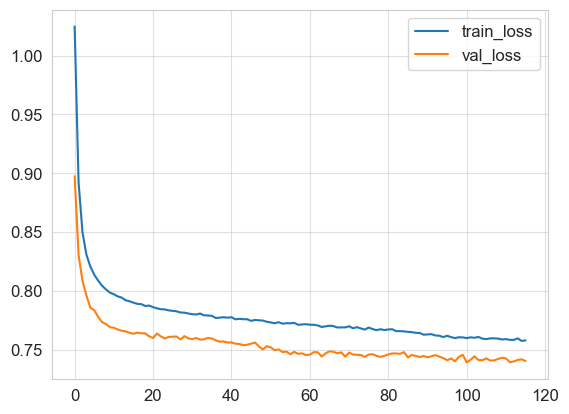

In [34]:
plt.plot(loss_history['train_loss'], label='train_loss')
plt.plot(loss_history['val_loss'], label='val_loss')
plt.legend()
plt.grid(alpha=0.6)
plt.show()

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
saved_weights = torch.load('best_model.pth', map_location=device)
model.load_state_dict(saved_weights)
model.to(device)
model.eval()

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=63, out_features=48, bias=True)
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=48, out_features=24, bias=True)
    (5): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.25, inplace=False)
    (8): Linear(in_features=24, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=24, bias=True)
    (1): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=24, out_features=48, bias=True)
    (5): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.25, inplace=False)
    (8): Linear(in_features=48, out_features=63, bias=T

In [16]:
#extract latent features for all data
model.eval()
X_train_tensor_full = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)

with torch.no_grad():
    _, Z_train = model(X_train_tensor_full)
    _, Z_test = model(X_test_tensor)

Z_train = Z_train.numpy()
Z_test = Z_test.numpy()

latent_cols = []
for i in range(latent_dim):
    latent_cols.append(f'Z{i+1}')

## Mixed-Effects/Clustered Model

In [18]:
df_train_mixed = pd.DataFrame(Z_train, columns=latent_cols)
df_train_mixed['match'] = y_train
df_train_mixed['gender'] = df.loc[train_idx, 'gender'].values  
df_train_mixed['iid'] = df.loc[train_idx, 'iid'].values
print(f"df_train_mixed:\n{df_train_mixed}\n")
# print("df_train_mixed:")
# display(df_train_mixed)

df_test_mixed = pd.DataFrame(Z_test, columns=latent_cols)
df_test_mixed['match'] = y_test
df_test_mixed['gender'] = df.loc[test_idx, 'gender'].values
df_test_mixed['iid'] = df.loc[test_idx, 'iid'].values
print(f"df_test_mixed:\n{df_test_mixed}")
# print("\ndf_train_mixed:")
# display(df_train_mixed)

df_train_mixed:
             Z1        Z2        Z3        Z4        Z5        Z6        Z7  \
0     -1.747110  1.489153 -2.134449  0.534866 -2.783435 -0.164540  1.749026   
1     -1.838121  1.354654 -2.039197  0.525045 -2.718314 -0.325806  1.625327   
2     -2.258906  0.742230 -1.160608  0.246522 -1.983297 -0.666435  0.547740   
3     -2.368934  0.546927 -0.912932 -0.049517 -1.807378 -0.792915  0.322798   
4     -2.376184  0.543871 -0.926225 -0.047583 -1.826773 -0.824628  0.337361   
...         ...       ...       ...       ...       ...       ...       ...   
26969  0.235052  1.033108 -1.148800 -0.624110 -0.894299 -1.401394 -0.352499   
26970  0.250671  1.092076 -1.188257 -0.656292 -0.904391 -1.459975 -0.389952   
26971  0.174723  1.018089 -1.056284 -0.848095 -0.771709 -1.596167 -0.586185   
26972  0.154962  1.029189 -1.093153 -0.848362 -0.759210 -1.681243 -0.576010   
26973  0.340220  1.857790 -3.222022  1.592241 -1.201119 -1.976969 -0.989448   

             Z8  match  gender  iid

#### Generalized Estimating Equation (GEE) for Binary Data

In [19]:
main_effects = ' + '.join(latent_cols)
interaction_terms = ' + '.join([f'gender:{col}' for col in latent_cols])
formula = f"match ~ {main_effects} + gender + {interaction_terms}"
print(f"Model formula: {formula}")

Model formula: match ~ Z1 + Z2 + Z3 + Z4 + Z5 + Z6 + Z7 + Z8 + gender + gender:Z1 + gender:Z2 + gender:Z3 + gender:Z4 + gender:Z5 + gender:Z6 + gender:Z7 + gender:Z8


In [20]:
#fitting models: GEE model with a Binomial logit link, clustered at the participant level (iid) & null baseline model
mixed_model = sm.GEE.from_formula(
    formula, 
    groups=df_train_mixed['iid'], 
    data=df_train_mixed, 
    family=sm.families.Binomial()
)
result = mixed_model.fit()
print(result.summary())

# Fit null model for baseline comparison
null_model = sm.GEE.from_formula(
    "match ~ 1", 
    groups=df_train_mixed['iid'], 
    data=df_train_mixed, 
    family=sm.families.Binomial()
)
null_result = null_model.fit()
print(f"\n\n{null_result.summary()}")

                               GEE Regression Results                              
Dep. Variable:                       match   No. Observations:                26974
Model:                                 GEE   No. clusters:                      260
Method:                        Generalized   Min. cluster size:                  10
                      Estimating Equations   Max. cluster size:                 231
Family:                           Binomial   Mean cluster size:               103.7
Dependence structure:         Independence   Num. iterations:                     2
Date:                     Fri, 29 May 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         03:55:48
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9333      0.177     -5.268      0.000      -1.281      -0.586
Z1     

In [22]:
# Model Comparison via QIC (Quasi-likelihood Information Criterion)
full_qic, full_qicu = result.qic()
null_qic, null_qicu = null_result.qic()
print(f"Null Model (Intercept Only) QIC: {null_qic:<10.3f} |  QICu: {null_qicu:.3f}")
print(f"Full Model (Latent + Sex)   QIC: {full_qic:<10.3f} |  QICu: {full_qicu:.3f}")
delta_qic = null_qic - full_qic
print(f"\nQIC Improvement (Null QIC - Full QIC): {delta_qic:.3f}")

# Statistical interpretation using standard information criteria rules of thumb
if delta_qic > 10:
    print("Interpretation: Strong evidence that the autoencoder latent features substantially improve the model's explanatory power.")
elif delta_qic > 2:
    print("Interpretation: Moderate evidence that the full model improves over the null baseline.")
elif delta_qic >= -2:
    print("Interpretation: The latent features add negligible value; prefer the simpler model.")
else:
    print("Interpretation: The full model is overparameterized and performing worse than the null baseline.")

Null Model (Intercept Only) QIC: 24915.830  |  QICu: 24911.912
Full Model (Latent + Sex)   QIC: 21475.060  |  QICu: 21445.918

QIC Improvement (Null QIC - Full QIC): 3440.770
Interpretation: Strong evidence that the autoencoder latent features substantially improve the model's explanatory power.


In [23]:
## THESE MAY BE IRRELAVANT:
# predict probabilities directly on the test set
test_pred = result.predict(df_test_mixed)
auc = roc_auc_score(df_test_mixed['match'], test_pred)
brier = brier_score_loss(df_test_mixed['match'], test_pred)
print(f"Test ROC-AUC: {auc:.4f}\nTest Brier score: {brier:.4f}\n")

# Baseline ROC-AUC using only the intercept
null_test_pred = null_result.predict(df_test_mixed)
baseline_auc = roc_auc_score(df_test_mixed['match'], null_test_pred)
baseline_brier = brier_score_loss(df_test_mixed['match'], test_pred)
print(f"Null model Test ROC-AUC: {baseline_auc:.4f}\nNull model Test Brier score: {baseline_brier:.4f}")

delta_auc = auc - baseline_auc
delta_brier = brier - baseline_brier
print(f"\nAUC Improvement (Full AUC - Null AUC): {delta_auc:.3f}")
print(f"Brier Improvement (Full Brier - Null Brier): {delta_brier:.3f}")

Test ROC-AUC: 0.7981
Test Brier score: 0.1248

Null model Test ROC-AUC: 0.5000
Null model Test Brier score: 0.1248

AUC Improvement (Full AUC - Null AUC): 0.298
Brier Improvement (Full Brier - Null Brier): 0.000


In [24]:
#Post-hoc correlation of latent features with original feature
corr_matrix = np.corrcoef(np.hstack([X_train_scaled, Z_train]).T)
p = X_train_scaled.shape[1]
latent_corrs = corr_matrix[:p, p:]# rows: original features, cols: latent features
corr_df = pd.DataFrame(latent_corrs, index=feature_names, columns=latent_cols)

In [25]:
print(corr_df)

                                          Z1        Z2        Z3        Z4  \
gender                             -0.106754  0.348366 -0.083039 -0.322036   
condtn                             -0.012850  0.059732 -0.067007 -0.061186   
int_corr                            0.242969 -0.017471  0.129065 -0.005290   
samerace                            0.006723 -0.001061 -0.007524  0.044258   
age_o                               0.054806 -0.019032  0.015881 -0.010851   
...                                      ...       ...       ...       ...   
rating_ref_group_othersex_value    -0.036572 -0.075679  0.140960 -0.047815   
rating_ref_group_samesex_value     -0.018936 -0.058672  0.121019 -0.076698   
rating_ref_group_self_rating       -0.098291 -0.152276  0.297322 -0.236053   
rating_ref_group_self_value         0.193627  0.352119 -0.568997  0.211690   
rating_ref_group_self_valuing_post  0.006964  0.050011 -0.317676  0.656439   

                                          Z5        Z6        Z

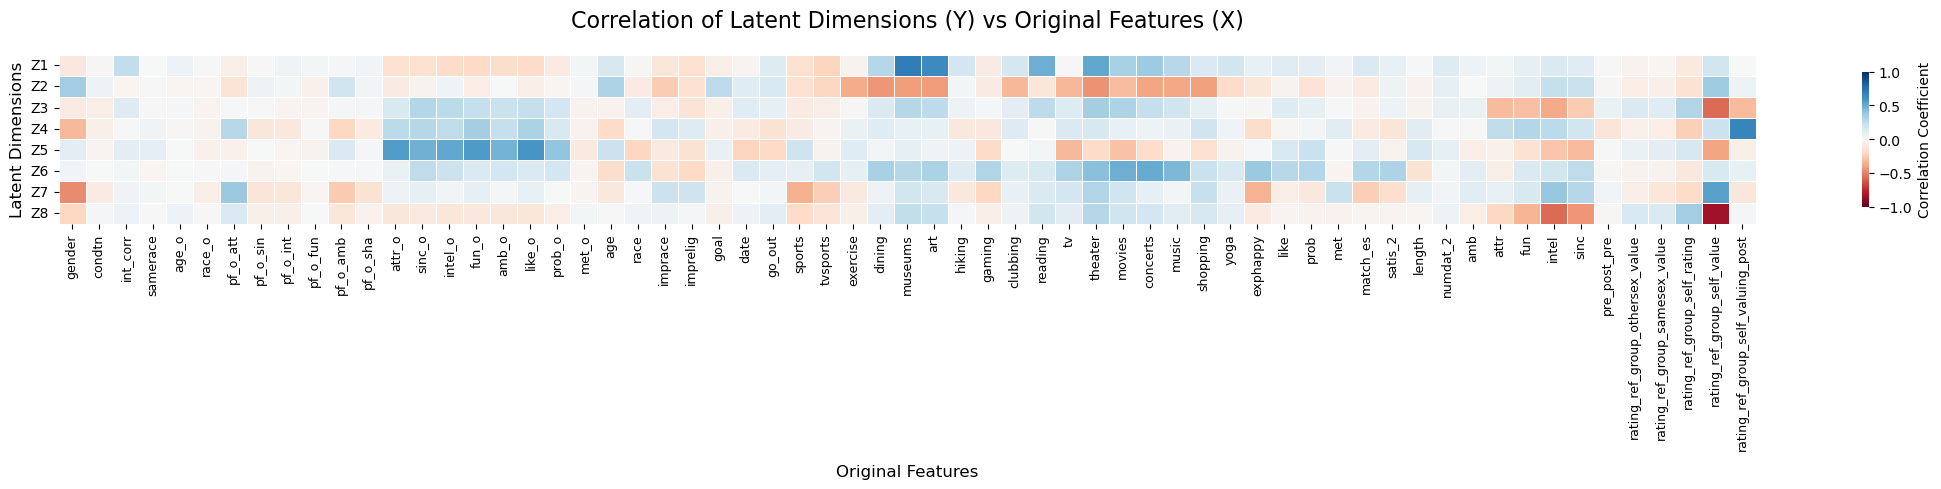

In [26]:
corr_df_transposed = corr_df.T
plt.figure(figsize=(22, 5))
sns.heatmap(
    corr_df_transposed,
    cmap='RdBu',
    vmax=1, vmin=-1, center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"}
)
plt.title('Correlation of Latent Dimensions (Y) vs Original Features (X)', fontsize=16, pad=20)
plt.xlabel('Original Features', fontsize=12, labelpad=10)
plt.ylabel('Latent Dimensions', fontsize=12)
plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

In [27]:
print("Top correlations of each latent dimension (Original Signs):")
for col in latent_cols:
    top5_idx = corr_df[col].abs().sort_values(ascending=False).head(5).index
    top5_original = corr_df.loc[top5_idx, col]
    print(f"\n{col}:")
    for feature, value in top5_original.items():
        print(f"{feature:<35} {value:+.6f}")

Top correlations of each latent dimension (Original Signs):

Z1:
museums                             +0.696499
art                                 +0.632897
theater                             +0.520060
reading                             +0.491449
concerts                            +0.366622

Z2:
theater                             -0.446302
dining                              -0.444107
art                                 -0.423163
museums                             -0.417349
shopping                            -0.408445

Z3:
rating_ref_group_self_value         -0.568997
intel                               -0.382116
theater                             +0.337661
rating_ref_group_self_valuing_post  -0.317676
attr                                -0.314116

Z4:
rating_ref_group_self_valuing_post  +0.656439
fun_o                               +0.337343
gender                              -0.322036
like_o                              +0.314355
fun                                 +0.293826
